# Práctica 2. Sensado y Análisis de Imagen
### Ciencia de Datos para Sensores Inteligentes/Tópicos Selectos en Sistemas Interactivos
Estudiante: Leon-Altamirano F. Z. C.

El objetivo de esta práctica es desarrollar un sistema de clasificación de personas basado en el análisis de la marcha. Se utilizarán técnicas de procesamiento de video, extracción de características y algoritmos de deep learning.

## Dataset
Consistente en 52 videos con longitudes variables, grabadas con una cámara RGBD Realsense, con una resolución 720p a 30fps.

Cada sujeto grabó 4 videos, caminando hacia la cámara.

El formato de los archivos es CLASE-MUESTRA.bag

CLASE:= indica el nombre del sujeto caminando.
MUESTRA:= número de muestra por cada clase.

## Importación de bibliotecas

In [219]:
import os
import re
from tqdm import tqdm
import random
import ast

# Data
import numpy as np
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mode
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.decomposition import PCA

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
import tensorflow as tf

# Video
import cv2
import pyrealsense2 as rs
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

## Extracción de Puntos Clave

In [220]:
dataset_path = './dataset'

In [221]:
dataset_df = pd.DataFrame(
    columns=[
        "file_name",
        "file_path",
        "student_id",
        "sample_number",
    ]
)

Cargamos los archivos de video y guardamos sus detalles en un DataFrame de pandas.

In [222]:
rows = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".bag"):
            file_path = os.path.join(root, file)
            match = re.match(r"([A-z]+)_([0-9]+)\.bag", file)
            if match:
                student_id = match.group(1)
                sample_number = match.group(2)
                
                rows.append(
                    {
                        "file_name": file,
                        "file_path": file_path,
                        "student_id": student_id,
                        "sample_number": sample_number,
                    }
                )

dataset_df = pd.concat([dataset_df, pd.DataFrame(rows)], ignore_index=True)

In [223]:
dataset_df.head()

,file_name,file_path,student_id,sample_number
0,DianaItzel_01.bag,./dataset\DianaItzel_01.bag,DianaItzel,01
1,DianaItzel_02.bag,./dataset\DianaItzel_02.bag,DianaItzel,02
2,DianaItzel_03.bag,./dataset\DianaItzel_03.bag,DianaItzel,03
3,DianaItzel_04.bag,./dataset\DianaItzel_04.bag,DianaItzel,04
4,DianaMinerva_01.bag,./dataset\DianaMinerva_01.bag,DianaMinerva,01


Seleccionamos un video al azar para inspeccionar sus metadatos.

In [224]:
video_aleatorio = random.choice(dataset_df['file_path'].tolist())
print(f"Inspeccionando archivo: {video_aleatorio}")

Inspeccionando archivo: ./dataset\Edgar_01.bag


In [225]:
def obtener_metadata_bag(file_path):
    """
    Extrae algunos metadatos del video
    """
    metadata = {}
    
    pipeline = rs.pipeline()
    config = rs.config()

    rs.config.enable_device_from_file(config, file_path, repeat_playback=False)
    
    try:

        profile = pipeline.start(config)
        playback = profile.get_device().as_playback()
        
        duracion_us = playback.get_duration()
        duracion_seg = duracion_us
        metadata['Duración (seg)'] = duracion_seg
        
        streams_info = []
        for stream in profile.get_streams():
            vsp = stream.as_video_stream_profile()
            
            tipo = stream.stream_type().name
            ancho = vsp.width()
            alto = vsp.height()
            fps = vsp.fps()
            formato = stream.format().name
            
            streams_info.append(f"{tipo}: {ancho}x{alto} @ {fps}FPS ({formato})")
            
        metadata['Streams Configurados'] = " | ".join(streams_info)
        metadata['Nombre Archivo'] = file_path.split('/')[-1]
        
    except Exception as e:
        metadata['Error'] = str(e)
    finally:
        pipeline.stop()
        
    return metadata

In [226]:
meta_datos = obtener_metadata_bag(video_aleatorio)

df_meta = pd.DataFrame([meta_datos]).T
df_meta.columns = ["Valor"]
display(df_meta)

,Valor
Duración (seg),0 days 00:00:12.951096
Streams Configurados,depth: 1280x720 @ 30FPS (z16) | color: 1280x72...
Nombre Archivo,dataset\Edgar_01.bag


Extraemos los joints que nos interesan.

In [227]:
# --- CONFIGURACIÓN ---
posing_model = "pose_landmarker_heavy.task"

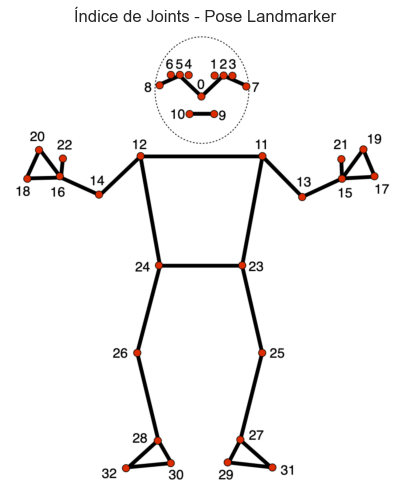

In [228]:
# Mostramos la imagen .png que tiene todos los joints para seleccionar los que nos interesan
display_png = cv2.imread('pose_landmarks_index.png')

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(display_png, cv2.COLOR_BGR2RGB))
plt.title("Índice de Joints - Pose Landmarker")
plt.axis('off')
plt.show()

Consideramos que los joints de interés son: 0, 11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,. Corresponden a la cabeza, hombros, codos, muñecas, caderas, rodillas y tobillos.

In [ ]:
JOINTS = [0, 11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]

In [ ]:
def extract_gait_points(file_path, joint_ids=JOINTS):
    """
    Procesa un archivo .bag y extrae las coordenadas 3D de los centros articulares.
    # """
    
    # --- INICIALIZAR MODELO ---
    base_options = python.BaseOptions(model_asset_path='pose_landmarker_heavy.task')
    options = vision.PoseLandmarkerOptions(
        base_options=base_options, 
        running_mode=vision.RunningMode.VIDEO
    )

    with vision.PoseLandmarker.create_from_options(options) as detector:

        resultados = []
        bad_frames = [] 
        
        # CONFIGURAR REALSENSE
        pipeline = rs.pipeline()
        config = rs.config()
        rs.config.enable_device_from_file(config, file_path, repeat_playback=False)
        
        # Iniciar pipeline
        profile = pipeline.start(config)
        playback = profile.get_device().as_playback()
        playback.set_real_time(False)
        align = rs.align(rs.stream.color)

        color_profile = profile.get_stream(rs.stream.color).as_video_stream_profile()
        width = color_profile.width()
        height = color_profile.height()
        
        last_timestamp_ms = -1
        frame_number = 0
        try:
            while True:
                # Obtener frames
                frames = pipeline.wait_for_frames(timeout_ms=5000)
                aligned_frames = align.process(frames)
                depth_frame = aligned_frames.get_depth_frame()
                color_frame = aligned_frames.get_color_frame()
                
                if not depth_frame or not color_frame:
                    break

                # Metadata del frame
                current_timestamp_ms = int(playback.get_position() / 1e6)

                if current_timestamp_ms <= last_timestamp_ms:
                    current_timestamp_ms = last_timestamp_ms + 1
                last_timestamp_ms = current_timestamp_ms

                # MediaPipe Detection
                color_image = np.asanyarray(color_frame.get_data())
                mp_image = mp.Image(
                    image_format=mp.ImageFormat.SRGB, 
                    data=cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)
                )
                
                # Detección
                detection_result = detector.detect_for_video(mp_image, current_timestamp_ms)

                if detection_result.pose_landmarks:
                    pose = detection_result.pose_landmarks[0]

                    # Extraer coordenadas
                    for joint_id in joint_ids:
                        lm = pose[joint_id]
                        
                        px = int(np.clip(lm.x * width, 0, width - 1))
                        py = int(np.clip(lm.y * height, 0, height - 1))
                        pz = depth_frame.get_distance(px, py)
                        
                        resultados.append({
                            'frame_number': frame_number,
                            'timestamp_ms': current_timestamp_ms,
                            'joint_id': joint_id,
                            'x_px': px,
                            'y_px': py,
                            'z_m': pz,
                        })
                else:
                        bad_frames.append({
                            'frame_number': frame_number,
                            'timestamp_ms': current_timestamp_ms,
                        })
                frame_number += 1

        except RuntimeError:
            pass  # end of bag file (timeout or EOF)
        except Exception as e:
            print(f"Error procesando {file_path}: {e}")
        finally:
            pipeline.stop()
        
    return resultados, bad_frames

In [ ]:
all_results = []
bad_frames_overall = []
for idx, row in tqdm(dataset_df.iterrows(), total=dataset_df.shape[0]):
    file_path = row['file_path']
    student_id = row['student_id']
    sample_number = row['sample_number']
    
    gait_points, bad_frames = extract_gait_points(file_path)
    bad_frames_overall.extend([{
        'student_id': student_id,
        'sample_number': sample_number,
        'bad_frames': bad_frames
    }])
    
    for point in gait_points:
        all_results.append({
            'student_id': student_id,
            'sample_number': sample_number,
            **point
        })
        
df_gait = pd.DataFrame(all_results)
df_bad_frames = pd.DataFrame(bad_frames_overall)

In [ ]:
df_gait.to_csv("gait_points_long.csv", index=False)
df_bad_frames.to_csv("bad_frames_summary.csv", index=False)

## Normalización y eliminación de ruido

In [155]:
df_gait = pd.read_csv("gait_points_long.csv")
df_bad_frames = pd.read_csv("bad_frames_summary.csv")

Graficamos la distribución de los frames para identificar posibles patrones o problemas en la captura de datos.

In [156]:
# x_px, y_px, z_m are numeric
df_gait['x_px'] = pd.to_numeric(df_gait['x_px'], errors='coerce')
df_gait['y_px'] = pd.to_numeric(df_gait['y_px'], errors='coerce')
df_gait['z_m'] = pd.to_numeric(df_gait['z_m'], errors='coerce')

In [157]:
df_bad_frames['bad_frames_list'] = df_bad_frames['bad_frames'].apply(ast.literal_eval)

# Extraer todos los timestamps donde falló la detección
all_bad_timestamps = []
for row in df_bad_frames['bad_frames_list']:
    for frame in row:
        all_bad_timestamps.append(frame['timestamp_ms'])

good_frames = df_gait[['student_id', 'sample_number', 'timestamp_ms']].drop_duplicates()['timestamp_ms']

In [158]:
# contamos la cantidad de frames con posición = 0, en x y z, para cada joint
zero_counts_x = df_gait[df_gait['x_px'] == 0].groupby('joint_id').size()
zero_counts_y = df_gait[df_gait['y_px'] == 0].groupby('joint_id').size()
zero_counts_z = df_gait[df_gait['z_m'] == 0].groupby('joint_id').size()

zero_counts_x = zero_counts_x.reindex(JOINTS, fill_value=0)
zero_counts_y = zero_counts_y.reindex(JOINTS, fill_value=0)
zero_counts_z = zero_counts_z.reindex(JOINTS, fill_value=0)

zero_counts_summary = pd.DataFrame({
    'joint_id': JOINTS,
    'zero_x_count': zero_counts_x.values,
    'zero_y_count': zero_counts_y.values,
    'zero_z_count': zero_counts_z.values
})

zero_counts_summary

,joint_id,zero_x_count,zero_y_count,zero_z_count
0,0,13,0,75
1,11,1,0,180
2,12,30,0,104
3,13,7,0,400
4,14,30,0,298
5,15,8,0,857
6,16,29,0,836
7,23,9,0,740
8,24,29,0,768
9,25,11,0,1475


Como se observa, la mayoría de los frames tienen dificultad en la detección de puntos en la coordenada z, principalmente los puntos debajo de la cintura.

In [159]:
zero_joints_ts = df_gait[df_gait['z_m'] == 0]['timestamp_ms']

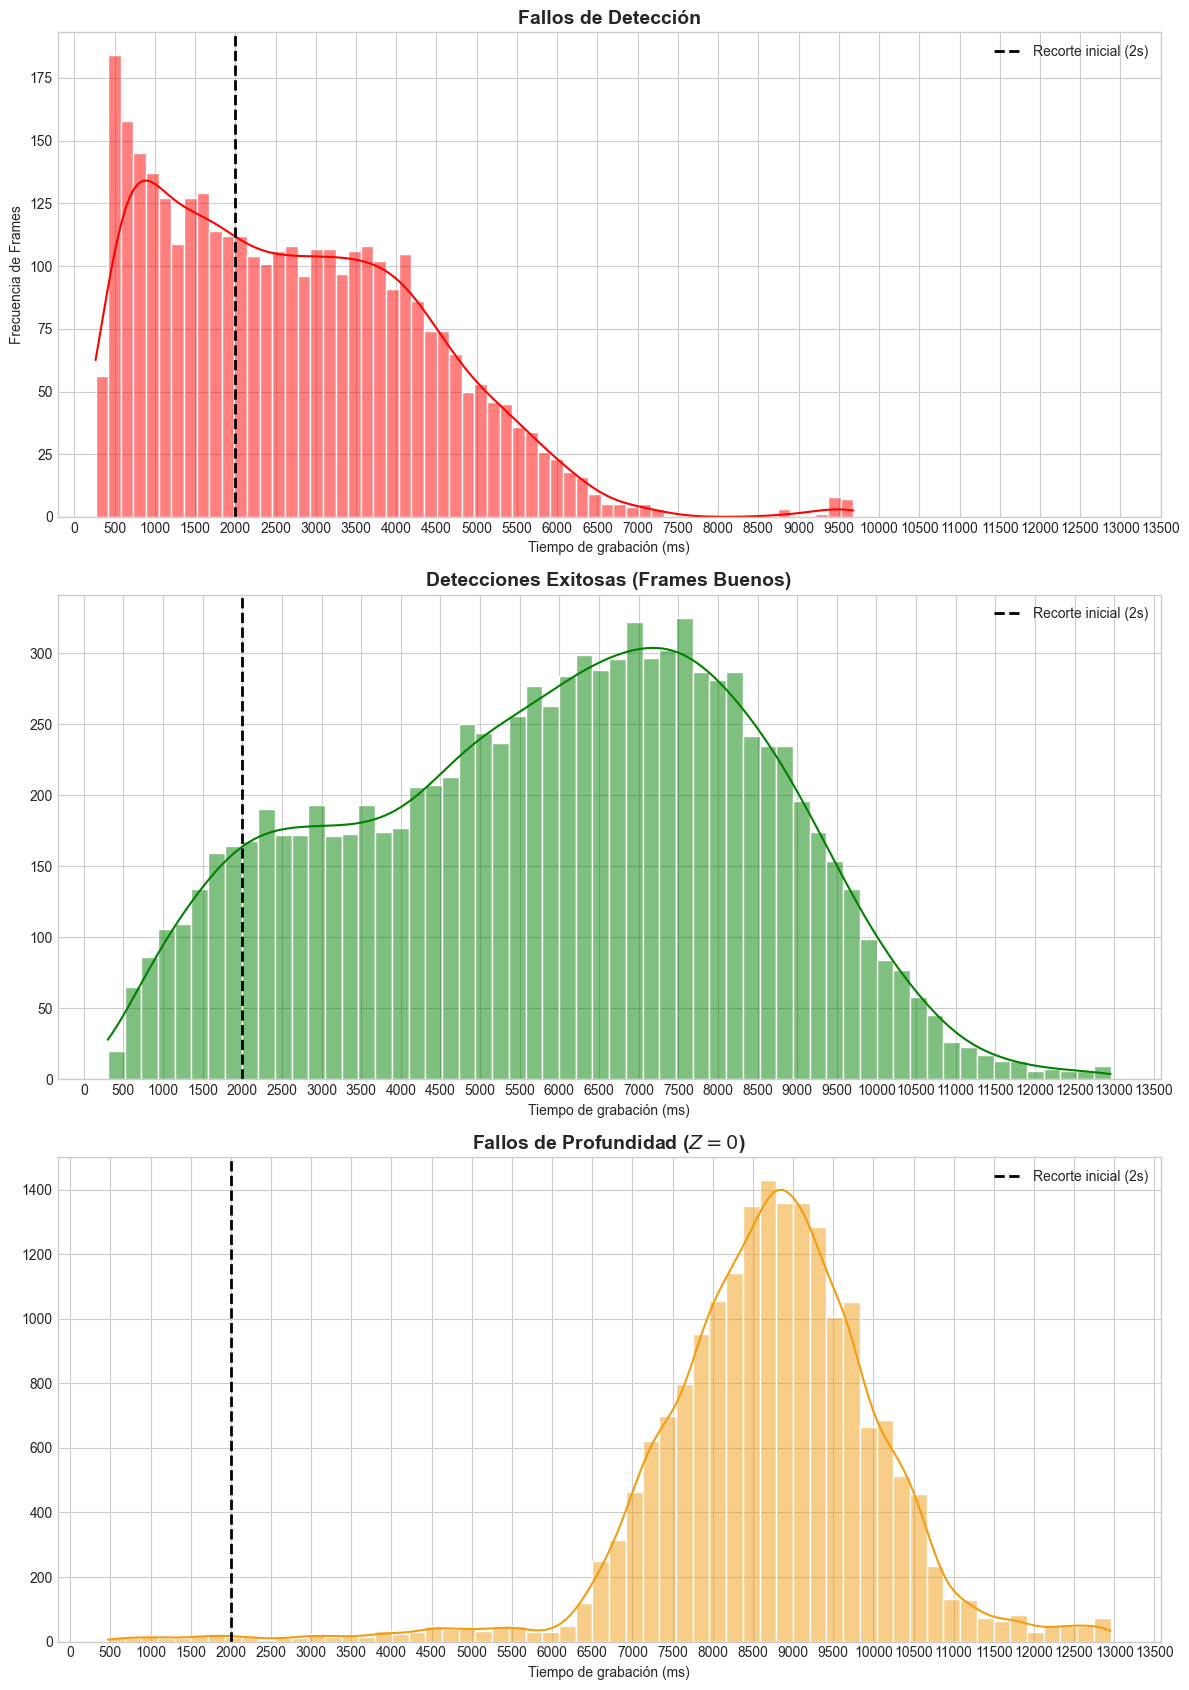

In [160]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(3, 1, figsize=(12, 17))

max_ts = max(max(all_bad_timestamps), max(good_frames), max(zero_joints_ts))
ticks_x = np.arange(0, max_ts + 1000, 500)

cut_off = 2000

# Histograma de frames con detección fallida
sns.histplot(all_bad_timestamps, bins=60, kde=True, color='red', edgecolor='white', alpha=0.5, ax=axes[0])
axes[0].axvline(cut_off, color='black', linestyle='--', linewidth=2, label='Recorte inicial (2s)')
axes[0].set_title('Fallos de Detección', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tiempo de grabación (ms)')
axes[0].set_ylabel('Frecuencia de Frames')
axes[0].set_xticks(ticks_x)
axes[0].legend(

)

# Histograma de frames con detección exitosa
sns.histplot(good_frames, bins=60, kde=True, color='green', edgecolor='white', alpha=0.5, ax=axes[1])
axes[1].axvline(cut_off, color='black', linestyle='--', linewidth=2, label='Recorte inicial (2s)')
axes[1].set_title('Detecciones Exitosas (Frames Buenos)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tiempo de grabación (ms)')
axes[1].set_ylabel('')
axes[1].set_xticks(ticks_x)
axes[1].legend()

# Histograma de frames con coordenada z = 0 (fallos de profundidad)
sns.histplot(zero_joints_ts, bins=60, kde=True, color='#f39c12', edgecolor='white', alpha=0.5, ax=axes[2])
axes[2].axvline(cut_off, color='black', linestyle='--', linewidth=2, label='Recorte inicial (2s)')
axes[2].set_title('Fallos de Profundidad ($Z=0$)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Tiempo de grabación (ms)')
axes[2].set_ylabel('')
axes[2].set_xticks(ticks_x)
axes[2].legend()

plt.tight_layout()
plt.show()

De los histogramas anteriores, se puede observar que el tiempo en el cual ocurren la mayoría de fallos de detección es principalmente al inicio. Por tal motivo, se decidió eliminar los frames con timestamp menor a 2000 ms.

Se realizará un recorte adaptativo, si a partir de cierto timestamp empiezan a aparecer fallos de detección, se eliminarán los frames posteriores a dicho timestamp.

In [161]:
def dynamic_cut_gait(df, start_ms=2000, quality_threshold=0.8):
    cleaned_chunks = []

    for (sid, sn), group in df.groupby(["student_id", "sample_number"]):
        # Recorte inicial
        video = group[group["timestamp_ms"] >= start_ms].copy()
        if video.empty:
            continue

        # Calidad por frame y encontrar el último punto estable
        frame_quality = video.groupby("timestamp_ms")["z_m"].apply(
            lambda x: (x > 0).mean()
        )
        valid_ts = frame_quality[frame_quality >= quality_threshold].index

        if len(valid_ts) == 0:
            continue

        # Recorte dinámico al último timestamp bueno
        video = video[video["timestamp_ms"] <= valid_ts.max()].copy()

        # Tratamos los valores de z_m <= 0 como fallos de detección y los marcamos como NaN para interpolar
        video.loc[video["z_m"] <= 0, "z_m"] = np.nan

        columns_to_interpolate = ["x_px", "y_px", "z_m"]

        for jid, jgroup in video.groupby("joint_id"):
            sorted_g = jgroup.sort_values("timestamp_ms")
            for c in columns_to_interpolate:
                video.loc[sorted_g.index, c] = (
                    sorted_g[c].interpolate(method="linear").bfill().ffill()
                )

        cleaned_chunks.append(video)

    return pd.concat(cleaned_chunks, ignore_index=True)

In [162]:
df_gait_cleaned = dynamic_cut_gait(df_gait, start_ms=2000, quality_threshold=0.8)

In [163]:
df_gait_cleaned.to_csv("gait_points_cleaned.csv", index=False)

## Extracción de características

In [164]:
df_gait_cleaned = pd.read_csv("gait_points_cleaned.csv")

Pasamos del formato long a un formato wide, donde cada fila corresponde a un frame y cada columna corresponde a una coordenada de un joint específico. Esto facilitará la extracción de características.

In [165]:
df_wide = df_gait_cleaned.pivot_table(
    index=['student_id', 'sample_number', 'timestamp_ms'],
    columns='joint_id',
    values=['x_px', 'y_px', 'z_m']
)

In [166]:
df_wide.columns = [f"{col}_{int(joint)}" for col, joint in df_wide.columns]
df_wide = df_wide.reset_index()

In [167]:
df_wide.head()

,student_id,sample_number,timestamp_ms,x_px_0,x_px_11,x_px_12,x_px_13,x_px_14,x_px_15,x_px_16,...,z_m_23,z_m_24,z_m_25,z_m_26,z_m_27,z_m_28,z_m_29,z_m_30,z_m_31,z_m_32
0,DianaItzel,1,2009,557.0,569.0,548.0,574.0,542.0,575.0,542.0,...,10.312000,9.618000,9.482000,9.904000,10.003000,10.873000,10.155001,10.873000,10.260000,10.420
1,DianaItzel,1,2038,558.0,571.0,549.0,575.0,542.0,576.0,543.0,...,9.953000,9.482000,9.712001,10.155001,10.003000,10.698001,10.104000,10.642000,10.207001,10.260
2,DianaItzel,1,2072,559.0,572.0,550.0,575.0,543.0,577.0,543.0,...,10.207001,9.437000,9.712001,10.155001,10.053000,10.585000,10.053000,10.698001,10.104000,10.260
3,DianaItzel,1,2105,559.0,573.0,550.0,576.0,544.0,578.0,544.0,...,9.953000,9.393001,9.904000,9.759001,10.155001,10.474001,10.155001,10.530001,10.104000,10.585
4,DianaItzel,1,2144,560.0,573.0,550.0,577.0,545.0,578.0,544.0,...,9.618000,9.219001,9.807000,9.482000,10.155001,10.207001,10.155001,10.104000,10.155001,10.642


La siguiente función convierte las coordenadas de píxeles a metros utilizando la profundidad para normalizar las medidas.

In [168]:
def convert_to_meters(df, joints, fx=640, fy=640, cx=640, cy=360):
    """
    Convierte x_px y y_px a coordenadas x_m y y_m usando la profundidad z_m.
    """
    for j in joints:
        # X_m = (x_px - cx) * z_m / fx
        df[f'x_m_{j}'] = (df[f'x_px_{j}'] - cx) * df[f'z_m_{j}'] / fx
        # Y_m = (y_px - cy) * z_m / fy
        df[f'y_m_{j}'] = (df[f'y_px_{j}'] - cy) * df[f'z_m_{j}'] / fy
    return df

La siguiente función es utilizada para extraer los ángulos articulares a partir de las coordenadas de los joints. Se calcula el ángulo entre tres puntos específicos para cada articulación de interés.

In [169]:
def extract_angles(df, p_a, p_b, p_c):
    """
    Extrae el ángulo entre tres puntos (p_a, p_b, p_c) para cada frame.
    """
    v_ba = np.array(
        [df[f"x_px_{p_a}"], df[f"y_px_{p_a}"], df[f"z_m_{p_a}"]]
    ) - np.array([df[f"x_px_{p_b}"], df[f"y_px_{p_b}"], df[f"z_m_{p_b}"]])

    v_bc = np.array(
        [df[f"x_px_{p_c}"], df[f"y_px_{p_c}"], df[f"z_m_{p_c}"]]
    ) - np.array([df[f"x_px_{p_b}"], df[f"y_px_{p_b}"], df[f"z_m_{p_b}"]])

    dot_product = np.einsum('ij,ij->j', v_ba, v_bc)
    norm_ba = np.linalg.norm(v_ba, axis=0)
    norm_bc = np.linalg.norm(v_bc, axis=0)

    denom = norm_ba * norm_bc
    mask = denom > 0
    cosine_angle = np.full_like(denom, np.nan)
    np.divide(dot_product, denom, out=cosine_angle, where=mask)

    return np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))

La siguiente función extrae las características de interés: ángulos articulares y métricas espacio-temporales.

In [170]:
def extraer_features(df_wide):
    df = df_wide.copy()
    
    # --- ÁNGULOS ARTICULARES ---
    # Rodillas
    df['ang_rodilla_izq'] = extract_angles(df, 23, 25, 27)
    df['ang_rodilla_der'] = extract_angles(df, 24, 26, 28)
    # Caderas
    df['ang_cadera_izq'] = extract_angles(df, 11, 23, 25)
    df['ang_cadera_der'] = extract_angles(df, 12, 24, 26)
    # Tobillos (Punta del pie)
    df['ang_tobillo_izq'] = extract_angles(df, 25, 27, 31)
    df['ang_tobillo_der'] = extract_angles(df, 26, 28, 32)
    
    # --- Métricas de los pasos ---
    # Longitud de paso (distancia entre pies en eje Z)
    df['longitud_paso'] = np.abs(df['z_m_29'] - df['z_m_30'])
    # Ancho de paso (distancia entre pies en eje X)
    df['ancho_paso'] = np.abs(df['x_m_29'] - df['x_m_30'])
    
    return df

In [171]:
def gen_features_vector(df_features, feature_columns):
    feature_vectors = []
    
    for (sid, sn), group in df_features.groupby(['student_id', 'sample_number']):
        vector = group[feature_columns].mean().values
        feature_vectors.append({
            'student_id': sid,
            'sample_number': sn,
            **{col: vector[i] for i, col in enumerate(feature_columns)}
        })
    
    return pd.DataFrame(feature_vectors)

In [172]:
df_wide_m = convert_to_meters(df_wide, JOINTS)

In [173]:
df_wide_m.to_csv("gait_points_wide_meters.csv", index=False)

In [174]:
df_signals = extraer_features(df_wide_m)
df_signals.head()

,student_id,sample_number,timestamp_ms,x_px_0,x_px_11,x_px_12,x_px_13,x_px_14,x_px_15,x_px_16,...,x_m_32,y_m_32,ang_rodilla_izq,ang_rodilla_der,ang_cadera_izq,ang_cadera_der,ang_tobillo_izq,ang_tobillo_der,longitud_paso,ancho_paso
0,DianaItzel,1,2009,557.0,569.0,548.0,574.0,542.0,575.0,542.0,...,-1.449031,-0.797781,173.914844,177.938613,170.325186,171.113137,178.941989,162.850394,0.717999,0.318622
1,DianaItzel,1,2038,558.0,571.0,549.0,575.0,542.0,576.0,543.0,...,-1.426781,-0.769500,176.962512,174.753392,168.910765,174.970906,176.706222,166.001006,0.538000,0.309947
2,DianaItzel,1,2072,559.0,572.0,550.0,575.0,543.0,577.0,543.0,...,-1.426781,-0.769500,176.622900,176.967894,167.164019,172.695834,176.810313,166.509353,0.645000,0.323297
3,DianaItzel,1,2105,559.0,573.0,550.0,576.0,544.0,578.0,544.0,...,-1.471977,-0.793875,179.236751,173.890030,167.401454,175.376218,174.264840,166.739385,0.375000,0.256078
4,DianaItzel,1,2144,560.0,573.0,550.0,577.0,545.0,578.0,544.0,...,-1.463275,-0.814778,177.473257,178.008287,171.500468,171.167385,174.293567,161.584314,0.051001,0.183712


In [175]:
df_signals.to_csv("gait_signals.csv", index=False)

In [176]:
features = [
    "ang_rodilla_izq",
    "ang_rodilla_der",
    "ang_cadera_izq",
    "ang_cadera_der",
    "ang_tobillo_izq",
    "ang_tobillo_der",
    "longitud_paso",
    "ancho_paso",
]

In [177]:
scaler = StandardScaler()
df_pca = df_signals.copy()
df_pca[features] = scaler.fit_transform(df_pca[features])

In [178]:
df_pca_input = df_pca.groupby(['student_id', 'sample_number'])[features].mean().reset_index()

X_pca_input = df_pca_input[features]
y_pca_labels = df_pca_input['student_id']

In [179]:
def plot_pca_analysis(X_pca_input, y_pca_labels, features_cols):
    """
    Ejecuta el análisis de PCA y genera la gráfica de solapamiento de clases,
    además de mostrar la influencia de cada característica.
    """
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(X_pca_input)

    # Configurar y generar la gráfica
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x=pca_results[:, 0], 
        y=pca_results[:, 1], 
        hue=y_pca_labels, 
        palette='turbo', 
        s=150, 
        alpha=0.8,
        edgecolor='black',
        style=y_pca_labels
    )

    # Añadir métricas de varianza en los ejes
    plt.title("Solapamiento de Clases (PCA) - Promedio por Video", fontsize=15)
    plt.xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0]:.1%})")
    plt.ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1]:.1%})")
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Individuos')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    plt.show()

    loadings = pd.DataFrame(
        pca.components_.T, 
        columns=['PC1', 'PC2'], 
        index=features_cols
    )
    
    print("\nInfluencia de las características en los componentes:")
    print(loadings.abs().sort_values(by='PC1', ascending=False))
    
    return pca 

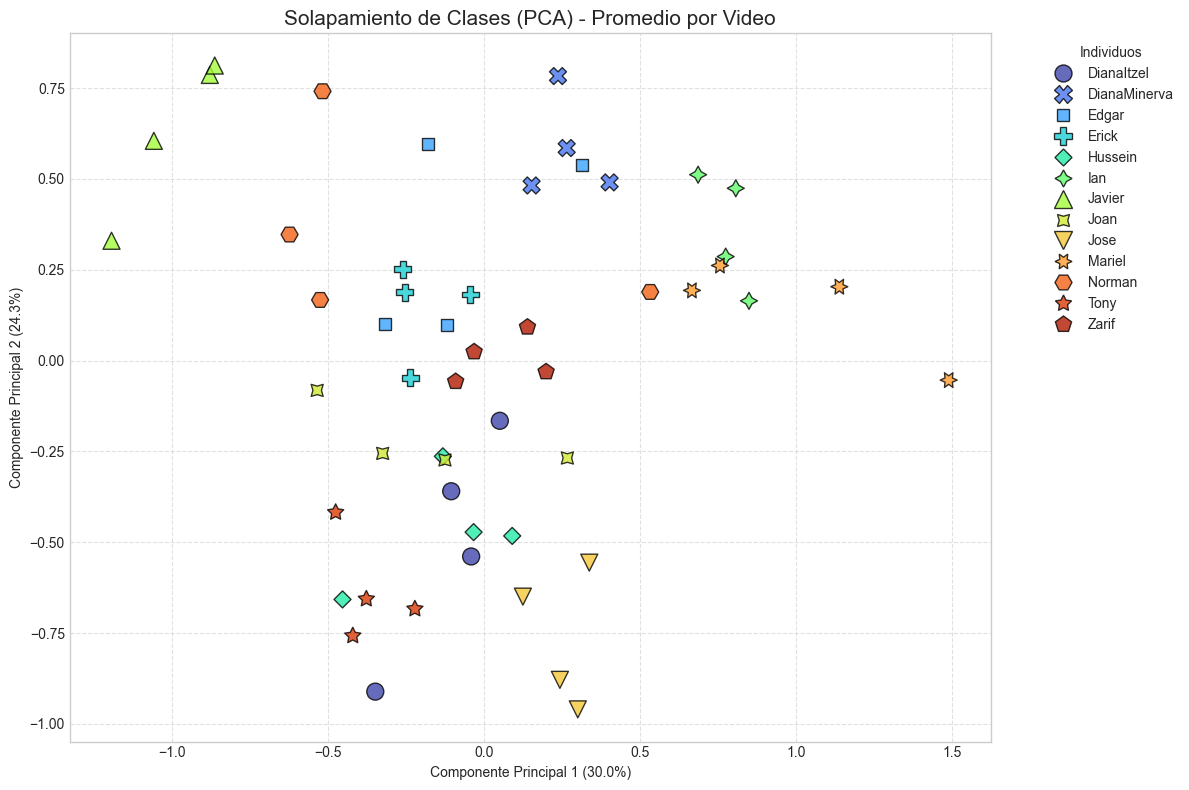


Influencia de las características en los componentes:
                      PC1       PC2
ang_cadera_der   0.664110  0.336886
ancho_paso       0.576906  0.269268
ang_rodilla_der  0.249039  0.101897
ang_tobillo_der  0.243120  0.273193
longitud_paso    0.215552  0.245471
ang_cadera_izq   0.193062  0.766142
ang_rodilla_izq  0.115047  0.180390
ang_tobillo_izq  0.089654  0.221844


In [180]:
pca=plot_pca_analysis(
    X_pca_input = df_pca_input[features], 
    y_pca_labels = df_pca_input['student_id'], 
    features_cols = features
)

## Construcción y Evaluación de Modelos

Como se utilizarán modelos de Deep Learning, se crearán ventanas de tiempo.

In [181]:
def create_time_windows(df, window_size=60, step_size=30, features_columns=None):
    """
    Crea ventanas de tiempo para cada muestra.
    """
    X, y, video_keys = [], [], []

    for (sid, sn), group in df.groupby(['student_id', 'sample_number']):
        data = group[features_columns].values

        for start in range(0, len(data) - window_size + 1, step_size):
            ventana = data[start:start + window_size]
            X.append(ventana)
            y.append(sid)

            # añadimos la etiqueta del video
            video_keys.append(f"{sid}_{sn}")

    return np.array(X), np.array(y), np.array(video_keys)

In [182]:
X_raw, y_raw, video_ids_raw = create_time_windows(df_signals, window_size=30, step_size=15, features_columns=features)

In [183]:
unique_video_keys = np.unique(video_ids_raw)
print(f"Videos únicos encontrados: {len(unique_video_keys)}")

Videos únicos encontrados: 50


**Nota**: Para ventanas de 30 frames, se pierden 2 videos (de la clase Javier, específicamente). Esto se abordará en la sección de discusión de resultados.

Normalizamos los ángulos, pues tienen valores muy distintos a las métricas espacio-temporales y proporciones físicas. Esto es importante para que el modelo de Deep Learning pueda aprender de manera efectiva.

In [184]:
# Normalizar características (X)
N, T, F = X_raw.shape
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_raw.reshape(-1, F)).reshape(N, T, F)

# Convertir etiquetas (y)
encoder = LabelEncoder()
y_int = encoder.fit_transform(y_raw)
n_classes = len(np.unique(y_int))
y_onehot = to_categorical(y_int)

## Construcción y Evaluación de Modelos

### Definición de Modelos

Se utilizarán los modelos: LSTM, CNN1D y una combinación de ambos (CNN1D + LSTM).

In [185]:
def build_lstm(input_shape, n_classes):
    model = Sequential(
        [
            Input(shape=input_shape),
            LSTM(64, return_sequences=True),
            BatchNormalization(),
            Dropout(0.3),
            LSTM(32, return_sequences=False),
            Dropout(0.3),
            Dense(64, activation="relu"),
            BatchNormalization(),
            Dense(n_classes, activation="softmax"),
        ]
    )

    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model


def build_cnn1d(input_shape, n_classes):
    model = Sequential(
        [
            Input(shape=input_shape),
            Conv1D(filters=64, kernel_size=3, activation="relu"),
            BatchNormalization(),
            MaxPooling1D(pool_size=2),
            Conv1D(filters=128, kernel_size=3, activation="relu"),
            BatchNormalization(),
            MaxPooling1D(pool_size=2),
            Flatten(),
            Dense(64, activation="relu"),
            Dropout(0.5),
            Dense(n_classes, activation="softmax"),
        ]
    )

    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model


def build_cnn_lstm(input_shape, n_classes):
    model = Sequential(
        [
            Input(shape=input_shape),
            Conv1D(64, kernel_size=3, activation="relu", padding="same"),
            BatchNormalization(),
            LSTM(64, return_sequences=False),
            Dropout(0.4),
            Dense(64, activation="relu"),
            Dense(n_classes, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model

La siguiente función, es utilizada para establecer una semilla para garantizar la reproducibilidad de los resultados.

In [186]:
def set_global_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

### Entrenamiento

La siguiente función es utilizada para asignar la etiqueta de clase predicha a cada video basándose en la mayoría de las predicciones realizadas en las ventanas de tiempo.

In [187]:
def votacion_hard(y_preds_windows, video_ids_test, encoder, y_true_windows=None):
    video_results = []
    unique_videos = np.unique(video_ids_test)
    
    for vid in unique_videos:
        indices = np.where(video_ids_test == vid)[0]
        
        preds_video = y_preds_windows[indices]
        
        voto_ganador = mode(preds_video).mode
        
        resultado = {
            'video': vid,
            'pred': encoder.inverse_transform([voto_ganador])[0],
        }
        
        if y_true_windows is not None:
            real_label = y_true_windows[indices[0]]
            resultado['real'] = encoder.inverse_transform([real_label])[0]
            resultado['correcto'] = real_label == voto_ganador
        video_results.append(resultado)

    return pd.DataFrame(video_results)

La siguiente función es utilizada para realizar el entrenamiento y evaluación de los modelos utilizando validación cruzada con K-Fold.

In [205]:
def evaluate_with_kfold(
    model_builder, X, y_int, y_onehot, encoder, video_ids, n_classes, name, n_splits=4
):
    # Establecer semilla para reproducibilidad
    set_global_seed(42)
    # Group Kfold para evitar que ventanas del mismo video estén en train y test al mismo tiempo
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    groups = video_ids

    # Para guardar predicciones
    oof_preds = np.zeros((X.shape[0], n_classes))
    fold_accuracies = []
    all_video_results = []

    print(f"\n{'='*40}")
    print(f" EVALUANDO {name} CON STRATIFIED GROUP K-FOLD")
    print(f"{'='*40}")

    for i, (train_idx, val_idx) in enumerate(sgkf.split(X, y_int, groups=groups)):
        # Re-construir modelo para limpiar pesos
        model = model_builder((X.shape[1], X.shape[2]), n_classes)

        # Early stopping usando el set de validación del fold actual para evitar sobreajuste
        early_stop = EarlyStopping(
            monitor="val_loss", patience=15, restore_best_weights=True
        )

        # Entrenar
        model.fit(
            X[train_idx],
            y_onehot[train_idx],
            validation_data=(X[val_idx], y_onehot[val_idx]),
            epochs=100,
            batch_size=32,
            verbose=0,
            callbacks=[early_stop],
        )

        # Guardar predicciones de este fold
        preds_probs = model.predict(X[val_idx], verbose=0)
        oof_preds[val_idx] = preds_probs

        # Calcular accuracy del fold
        acc = model.evaluate(X[val_idx], y_onehot[val_idx], verbose=0)[1]
        fold_accuracies.append(acc)
        print(f"Fold {i+1}: Accuracy (Ventanas) = {acc:.4f}")

        # Evaluación por video para este fold
        res_video_fold = votacion_hard(
            y_preds_windows=np.argmax(preds_probs, axis=1),
            video_ids_test=video_ids[val_idx],
            encoder=encoder,
            y_true_windows=y_int[val_idx],
        )
        all_video_results.append(res_video_fold)

    # ==========================================
    # RESULTADOS POR VENTANA DE TIEMPO
    # ==========================================
    y_pred_final = np.argmax(oof_preds, axis=1)
    y_true_final = y_int

    # Métricas de ventana
    acc_window = np.mean(y_pred_final == y_true_final)
    f1_window = f1_score(y_true_final, y_pred_final, average="macro")
    print(f"\nAccuracy por Ventana: {acc_window:.2%}")
    print(f"F1-Score Macro por Ventana: {f1_window:.4f}")


    print(f"\n{'-'*20} NIVEL VENTANA {'-'*20}")
    print("\nReporte de Clasificación:")
    print(
        classification_report(y_true_final, y_pred_final, target_names=encoder.classes_)
    )

    # Matriz de confusión de ventanas
    cm_win = confusion_matrix(y_true_final, y_pred_final)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_win,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=encoder.classes_,
        yticklabels=encoder.classes_,
    )
    plt.title(f"Matriz de Confusión (Ventanas) - {name}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    # ==========================================
    # RESULTADOS POR VIDEO (por votación)
    # ==========================================
    print(f"\n{'-'*20} NIVEL VIDEO (VOTACIÓN) {'-'*20}")

    df_final_videos = pd.concat(all_video_results, ignore_index=True)

    # Métricas de video
    total_videos = len(df_final_videos)
    aciertos = df_final_videos["correcto"].sum()
    acc_video = aciertos / total_videos

    print(f"Videos Totales: {total_videos}")
    print(f"Videos Correctos: {aciertos}")
    print(f"Accuracy por Video: {acc_video:.2%}")

    f1_video = f1_score(
        df_final_videos["real"], df_final_videos["pred"], average="macro"
    )
    print(f"F1-Score Macro por Video: {f1_video:.4f}")

    # Matriz de Confusión de Videos
    labels = encoder.classes_
    cm_vid = confusion_matrix(
        df_final_videos["real"], df_final_videos["pred"], labels=labels
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_vid,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(f"Matriz de Confusión (Videos Completos) - {name}")
    plt.xlabel("Predicción (Votación)")
    plt.ylabel("Real")
    plt.show()

    print("\nReporte de Clasificación:")
    print(
        classification_report(
            df_final_videos["real"], df_final_videos["pred"], labels=labels
        )
    )

    return f1_video, acc_video


 EVALUANDO LSTM CON STRATIFIED GROUP K-FOLD
Fold 1: Accuracy (Ventanas) = 0.8469
Fold 2: Accuracy (Ventanas) = 0.7714
Fold 3: Accuracy (Ventanas) = 0.8990
Fold 4: Accuracy (Ventanas) = 0.8529

Accuracy por Ventana: 84.16%
F1-Score Macro por Ventana: 0.8212

-------------------- NIVEL VENTANA --------------------

Reporte de Clasificación:
              precision    recall  f1-score   support

  DianaItzel       0.77      0.68      0.72        25
DianaMinerva       0.80      0.75      0.77        16
       Edgar       0.89      0.92      0.90        51
       Erick       0.76      0.84      0.80        56
     Hussein       0.89      1.00      0.94        25
         Ian       0.82      0.88      0.85        26
      Javier       0.88      0.75      0.81        20
        Joan       0.76      0.62      0.68        21
        Jose       0.90      1.00      0.95        37
      Mariel       0.79      0.58      0.67        19
      Norman       0.93      0.85      0.89        33
        T

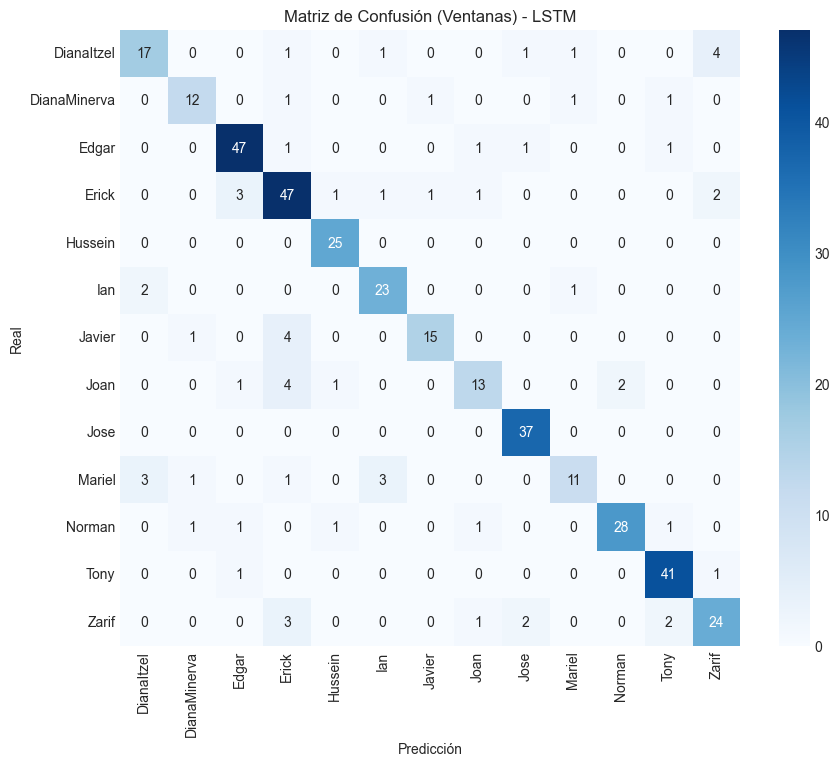


-------------------- NIVEL VIDEO (VOTACIÓN) --------------------
Videos Totales: 50
Videos Correctos: 45
Accuracy por Video: 90.00%
F1-Score Macro por Video: 0.8958


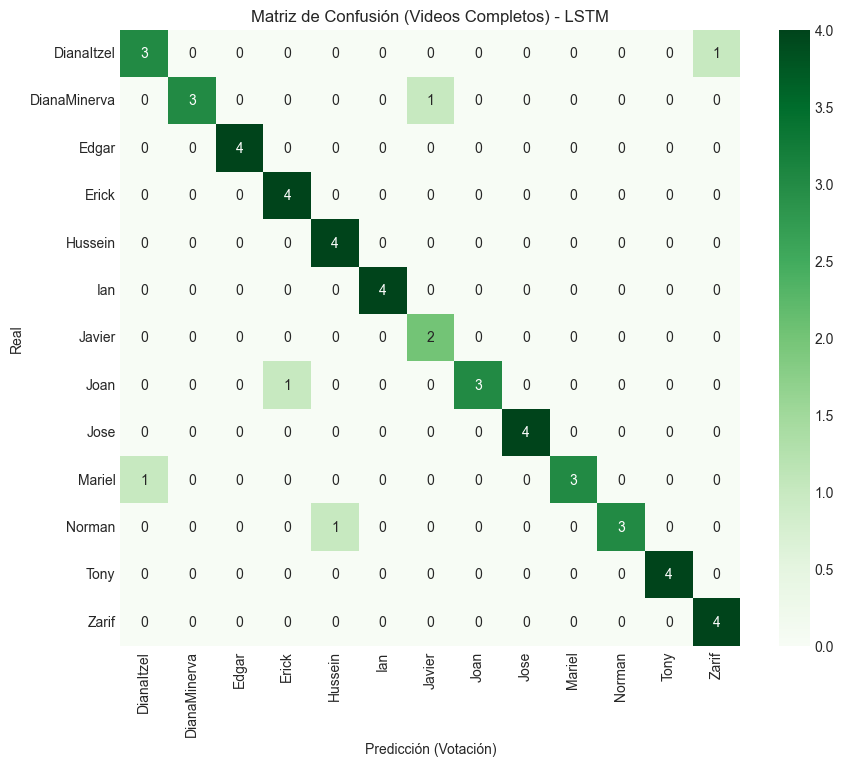


Reporte de Clasificación:
              precision    recall  f1-score   support

  DianaItzel       0.75      0.75      0.75         4
DianaMinerva       1.00      0.75      0.86         4
       Edgar       1.00      1.00      1.00         4
       Erick       0.80      1.00      0.89         4
     Hussein       0.80      1.00      0.89         4
         Ian       1.00      1.00      1.00         4
      Javier       0.67      1.00      0.80         2
        Joan       1.00      0.75      0.86         4
        Jose       1.00      1.00      1.00         4
      Mariel       1.00      0.75      0.86         4
      Norman       1.00      0.75      0.86         4
        Tony       1.00      1.00      1.00         4
       Zarif       0.80      1.00      0.89         4

    accuracy                           0.90        50
   macro avg       0.91      0.90      0.90        50
weighted avg       0.92      0.90      0.90        50


 EVALUANDO CNN-1D CON STRATIFIED GROUP K-FOLD
Fold 

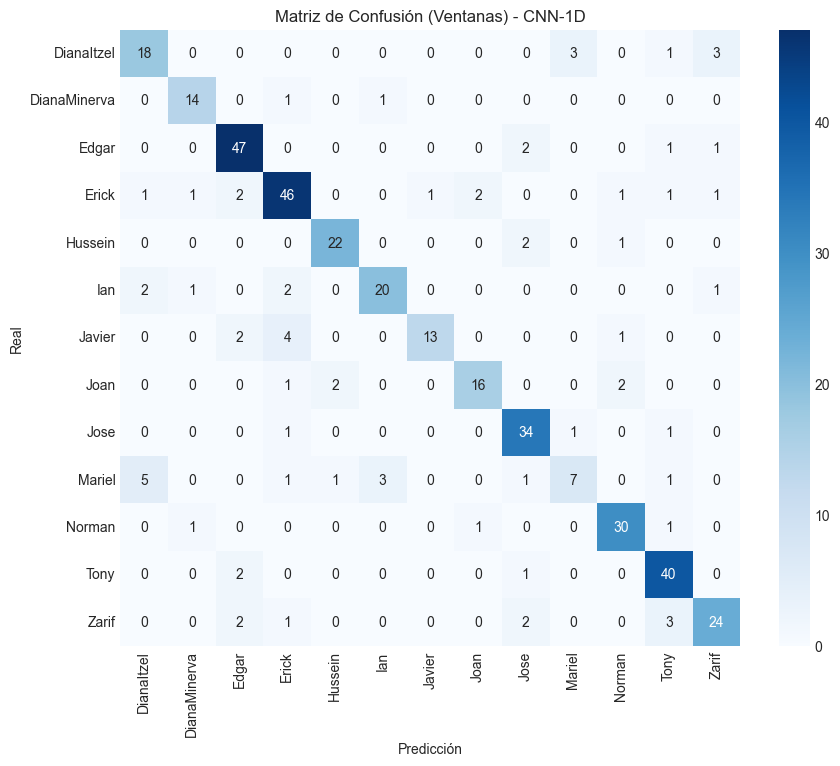


-------------------- NIVEL VIDEO (VOTACIÓN) --------------------
Videos Totales: 50
Videos Correctos: 46
Accuracy por Video: 92.00%
F1-Score Macro por Video: 0.9202


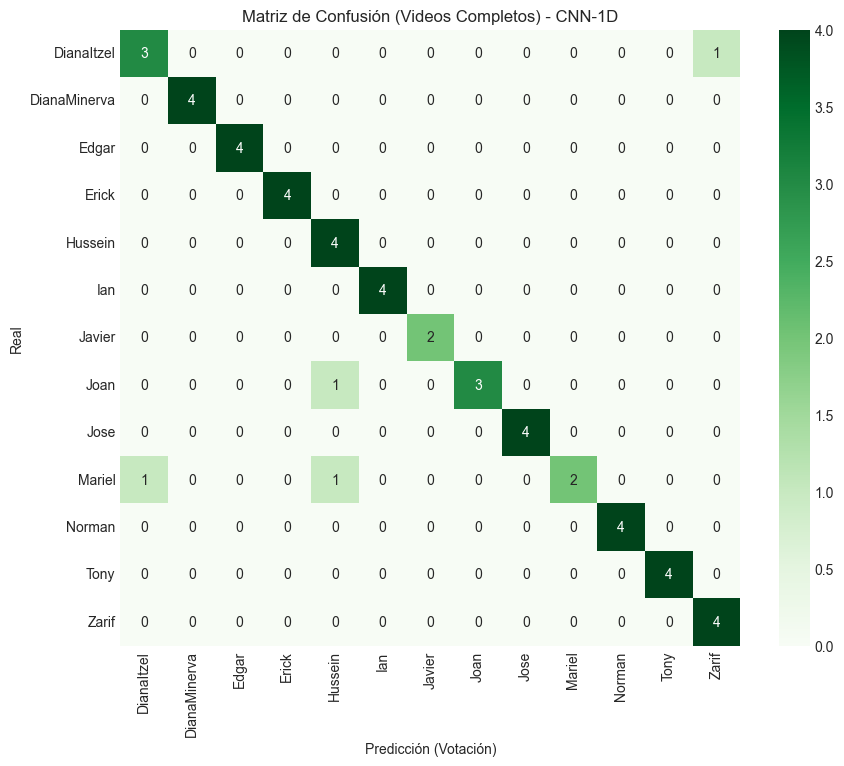


Reporte de Clasificación:
              precision    recall  f1-score   support

  DianaItzel       0.75      0.75      0.75         4
DianaMinerva       1.00      1.00      1.00         4
       Edgar       1.00      1.00      1.00         4
       Erick       1.00      1.00      1.00         4
     Hussein       0.67      1.00      0.80         4
         Ian       1.00      1.00      1.00         4
      Javier       1.00      1.00      1.00         2
        Joan       1.00      0.75      0.86         4
        Jose       1.00      1.00      1.00         4
      Mariel       1.00      0.50      0.67         4
      Norman       1.00      1.00      1.00         4
        Tony       1.00      1.00      1.00         4
       Zarif       0.80      1.00      0.89         4

    accuracy                           0.92        50
   macro avg       0.94      0.92      0.92        50
weighted avg       0.94      0.92      0.92        50


 EVALUANDO CNN-LSTM CON STRATIFIED GROUP K-FOLD
Fol

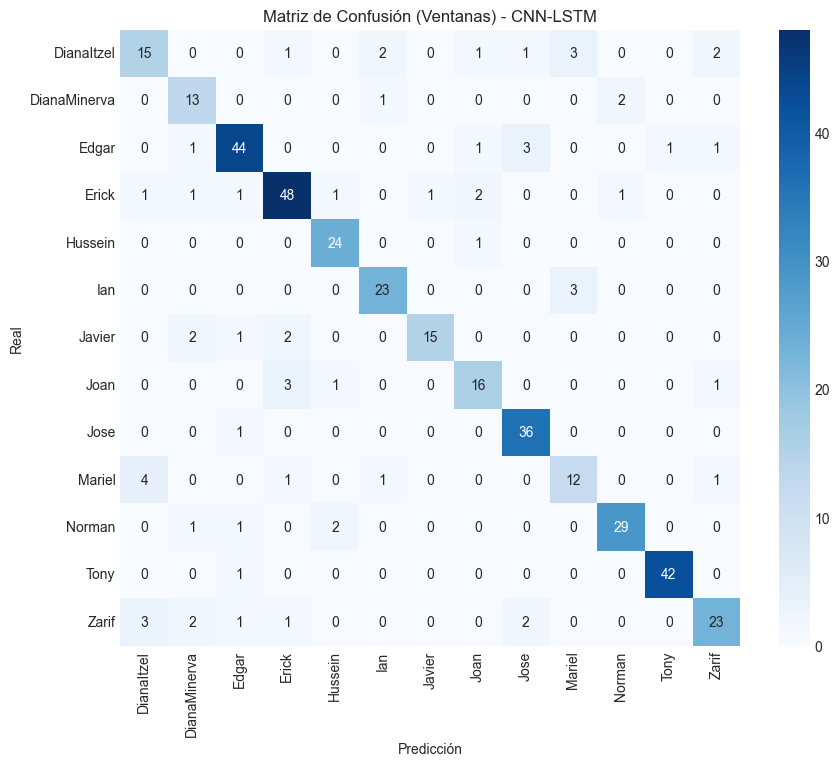


-------------------- NIVEL VIDEO (VOTACIÓN) --------------------
Videos Totales: 50
Videos Correctos: 46
Accuracy por Video: 92.00%
F1-Score Macro por Video: 0.9222


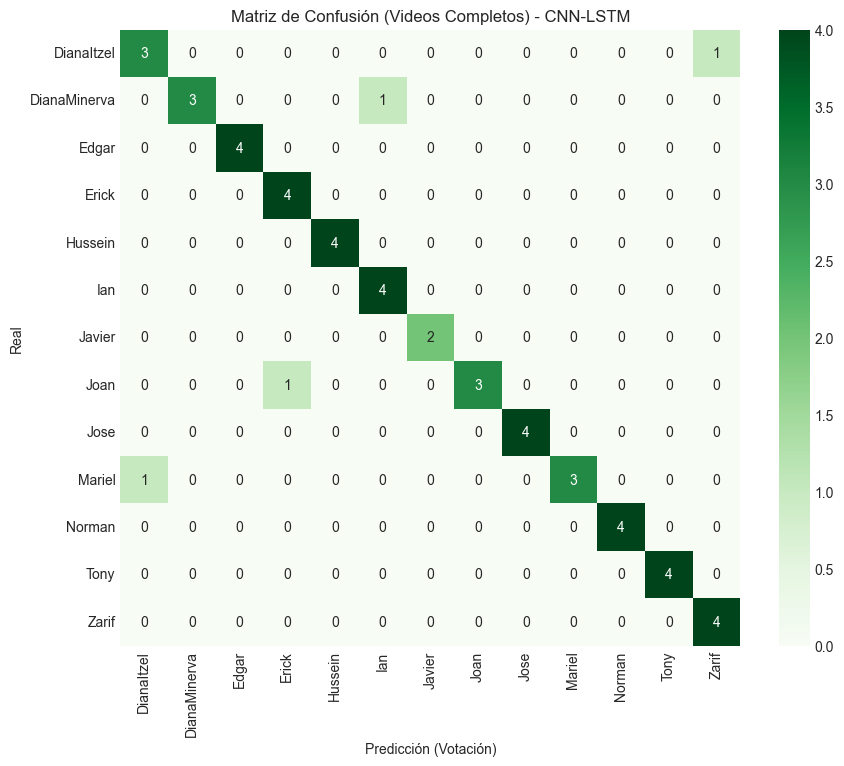


Reporte de Clasificación:
              precision    recall  f1-score   support

  DianaItzel       0.75      0.75      0.75         4
DianaMinerva       1.00      0.75      0.86         4
       Edgar       1.00      1.00      1.00         4
       Erick       0.80      1.00      0.89         4
     Hussein       1.00      1.00      1.00         4
         Ian       0.80      1.00      0.89         4
      Javier       1.00      1.00      1.00         2
        Joan       1.00      0.75      0.86         4
        Jose       1.00      1.00      1.00         4
      Mariel       1.00      0.75      0.86         4
      Norman       1.00      1.00      1.00         4
        Tony       1.00      1.00      1.00         4
       Zarif       0.80      1.00      0.89         4

    accuracy                           0.92        50
   macro avg       0.93      0.92      0.92        50
weighted avg       0.93      0.92      0.92        50


--- RESUMEN FINAL DE MODELOS ---
LSTM: F1-Score Mac

In [206]:
modelos_a_evaluar = {
    "LSTM": build_lstm,
    "CNN-1D": build_cnn1d,
    "CNN-LSTM": build_cnn_lstm
}

resultados_f1 = {}
resultados_acc_video = {}

# Entrenamos y evaluamos cada modelo
for nombre, constructor in modelos_a_evaluar.items():
    f1, acc_video = evaluate_with_kfold(
        model_builder=constructor,
        X=X_norm,       
        y_int=y_int,    
        y_onehot=y_onehot, 
        encoder=encoder,  
        video_ids=video_ids_raw,
        n_classes=n_classes,
        name=nombre
    )
    resultados_f1[nombre] = f1
    resultados_acc_video[nombre] = acc_video

print("\n--- RESUMEN FINAL DE MODELOS ---")
for m, score in resultados_f1.items():
    print(f"{m}: F1-Score Macro (Video) = {score:.4f}")

## Validación Externa

In [207]:
dataset_externo_path = './dataset-externo'

### Selección del Mejor Modelo y Re-entrenamiento

In [208]:
# Seleccionar el mejor modelo basado en F1-Score por video
best_model = max(resultados_f1, key=resultados_f1.get)
best_model_builder = modelos_a_evaluar[best_model]

print(f"Mejor modelo: {best_model} (F1-Video: {resultados_f1[best_model]:.4f})")

set_global_seed(42)

val_indices = []
train_indices = []

unique_classes = np.unique(y_int)
rng = np.random.RandomState(42)

# Entrenamos con Leave-One-Out para Early Stopping
for cls in unique_classes:
    cls_mask = y_int == cls
    cls_videos = np.unique(video_ids_raw[cls_mask])
    val_video = rng.choice(cls_videos, size=1)[0]
    for i in range(len(y_int)):
        if y_int[i] == cls:
            if video_ids_raw[i] == val_video:
                val_indices.append(i)
            else:
                train_indices.append(i)

train_indices = np.array(train_indices)
val_indices = np.array(val_indices)

print(f"Ventanas de entrenamiento: {len(train_indices)}")
print(f"Ventanas de validación: {len(val_indices)} (1 video por clase)")

modelo_final = best_model_builder((X_norm.shape[1], X_norm.shape[2]), n_classes)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

print("Entrenando modelo...")
modelo_final.fit(
    X_norm[train_indices], y_onehot[train_indices],
    validation_data=(X_norm[val_indices], y_onehot[val_indices]),
    epochs=1000,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

print("Modelo final entrenado exitosamente.")

Mejor modelo: CNN-LSTM (F1-Video: 0.9222)
Ventanas de entrenamiento: 286
Ventanas de validación: 118 (1 video por clase)
Entrenando modelo...
Epoch 1/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.1189 - loss: 2.5414 - val_accuracy: 0.1186 - val_loss: 2.5236
Epoch 2/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2972 - loss: 2.3449 - val_accuracy: 0.2034 - val_loss: 2.4858
Epoch 3/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4161 - loss: 2.1647 - val_accuracy: 0.2034 - val_loss: 2.4377
Epoch 4/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4860 - loss: 1.9975 - val_accuracy: 0.2458 - val_loss: 2.3757
Epoch 5/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5175 - loss: 1.7790 - val_accuracy: 0.2966 - val_loss: 2.2935
Epoch 6/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5839 - loss: 1.5670 - val_accuracy: 0.3305 - val_loss: 2.1856
Epoch 7/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6364 - loss: 1.3066 - val_accur

### Procesamiento del Dataset Externo

Nota: Se asignaron las etiquetas después de ver los videos, pero no se utilizaron para el entrenamiento, sino sólo para la evaluación final.

In [209]:
# Cargar archivos del dataset externo
ext_rows = []
for root, dirs, files in os.walk(dataset_externo_path):
    for file in files:
        if file.endswith(".bag"):
            file_path = os.path.join(root, file)
            match = re.match(r"([A-z]+)_([0-9]+)\.bag", file)
            if match:
                student_id = match.group(1)
                sample_number = match.group(2)
                ext_rows.append({
                    "file_name": file,
                    "file_path": file_path,
                    "student_id": student_id,
                    "sample_number": sample_number,
                })

dataset_ext_df = pd.DataFrame(ext_rows)
print(f"Videos externos encontrados: {len(dataset_ext_df)}")

Videos externos encontrados: 12


In [210]:
# Extraer puntos de la marcha del dataset externo
ext_all_results = []
ext_bad_frames = []

for idx, row in tqdm(dataset_ext_df.iterrows(), total=dataset_ext_df.shape[0], desc="Extrayendo Puntos Clave"):
    file_path = row['file_path']
    student_id = row['student_id']
    sample_number = row['sample_number']
    
    gait_points, bad_frames = extract_gait_points(file_path)
    ext_bad_frames.append({
        'student_id': student_id,
        'sample_number': sample_number,
        'bad_frames': bad_frames
    })
    
    for point in gait_points:
        ext_all_results.append({
            'student_id': student_id,
            'sample_number': sample_number,
            **point
        })

Extrayendo Puntos Clave: 100%|██████████| 12/12 [03:58<00:00, 19.91s/it]


In [211]:
df_gait_ext = pd.DataFrame(ext_all_results)

In [ ]:
# Limpieza
df_gait_ext['x_px'] = pd.to_numeric(df_gait_ext['x_px'], errors='coerce')
df_gait_ext['y_px'] = pd.to_numeric(df_gait_ext['y_px'], errors='coerce')
df_gait_ext['z_m'] = pd.to_numeric(df_gait_ext['z_m'], errors='coerce')

df_gait_ext_cleaned = dynamic_cut_gait(df_gait_ext, start_ms=2000, quality_threshold=0.8)

# Formato ancho para extracción de features
df_ext_wide = df_gait_ext_cleaned.pivot_table(
    index=['student_id', 'sample_number', 'timestamp_ms'],
    columns='joint_id',
    values=['x_px', 'y_px', 'z_m']
)
df_ext_wide.columns = [f"{col}_{int(joint)}" for col, joint in df_ext_wide.columns]
df_ext_wide = df_ext_wide.reset_index()

# Convertir a metros
df_ext_wide_m = convert_to_meters(df_ext_wide, JOINTS)

# Extraer features
df_ext_signals = extraer_features(df_ext_wide_m)

print(f"Frames procesados (dataset externo): {len(df_ext_signals)}")
print(f"Videos con datos validos: {df_ext_signals.groupby(['student_id', 'sample_number']).ngroups}")

Frames procesados (dataset externo): 1154
Videos con datos validos: 12


In [213]:
# Crear ventanas de tiempo (mismos parametros que entrenamiento)
X_ext_raw, _, video_ids_ext = create_time_windows(
    df_ext_signals, 
    window_size=30, 
    step_size=15, 
    features_columns=features
)

print(f"Ventanas generadas (externo): {X_ext_raw.shape[0]}")
print(f"Videos con ventanas: {len(np.unique(video_ids_ext))}")

# Normalizar con el mismo scaler del entrenamiento
N_ext, T_ext, F_ext = X_ext_raw.shape
X_ext_norm = scaler.transform(X_ext_raw.reshape(-1, F_ext)).reshape(N_ext, T_ext, F_ext)

Ventanas generadas (externo): 60
Videos con ventanas: 12


### Predicciones sobre Dataset Externo

In [214]:
# Predección por ventana
probs_ext = modelo_final.predict(X_ext_norm, verbose=0)

# Asignar etiquetas por video con votación
df_pred_externo = votacion_hard(
                y_preds_windows=np.argmax(probs_ext, axis=1),
                video_ids_test=video_ids_ext,
    encoder=encoder,
    y_true_windows=None
)

In [215]:
# Metricas por video
video_to_label = {}
for _, row in dataset_ext_df.iterrows():
    vid_key = f"{row['student_id']}_{row['sample_number']}"
    video_to_label[vid_key] = row['student_id']

df_pred_externo['real'] = df_pred_externo['video'].map(video_to_label)
df_pred_externo['correcto'] = df_pred_externo['real'] == df_pred_externo['pred']


total = len(df_pred_externo)
aciertos = df_pred_externo['correcto'].sum()
acc_ext = aciertos / total

f1_ext = f1_score(df_pred_externo['real'], df_pred_externo['pred'], average='macro')

print(f"Videos Totales: {total}")
print(f"Videos Correctos: {aciertos}")
print(f"Accuracy por Video: {acc_ext:.2%}")
print(f"F1-Score Macro por Video: {f1_ext:.4f}")

print("\nReporte de Clasificación:")
print(classification_report(df_pred_externo['real'], df_pred_externo['pred']))

Videos Totales: 12
Videos Correctos: 4
Accuracy por Video: 33.33%
F1-Score Macro por Video: 0.1667

Reporte de Clasificación:
              precision    recall  f1-score   support

       Erick       0.00      0.00      0.00         0
     Hussein       0.00      0.00      0.00         0
      Javier       0.00      0.00      0.00         0
        Joan       1.00      0.33      0.50         3
      Mariel       0.00      0.00      0.00         0
        Tony       1.00      1.00      1.00         3
       Zarif       0.00      0.00      0.00         0
       chica       0.00      0.00      0.00         3
       chico       0.00      0.00      0.00         3

    accuracy                           0.33        12
   macro avg       0.22      0.15      0.17        12
weighted avg       0.50      0.33      0.38        12



d:\CICESE\Materias\C2\CDSI\Practicas\Practica 2 - Imagen\imagen\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\CICESE\Materias\C2\CDSI\Practicas\Practica 2 - Imagen\imagen\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\CICESE\Materias\C2\CDSI\Practicas\Practica 2 - Imagen\imagen\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

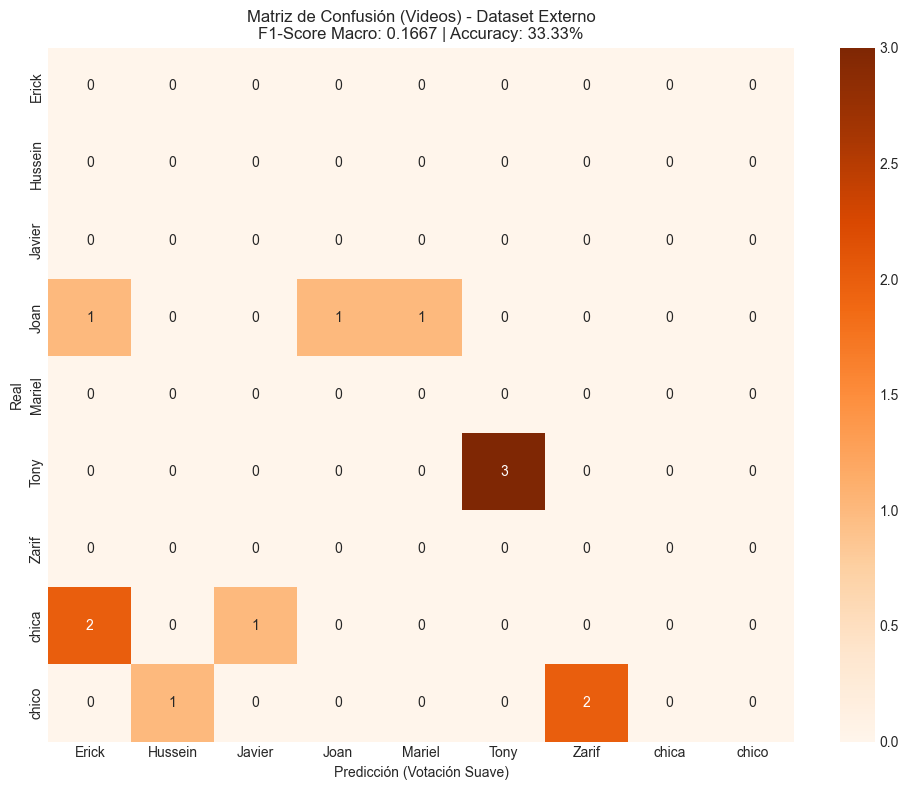

In [216]:
# Matriz de confusión por video (votación)
all_labels_ext = sorted(set(df_pred_externo['real'].tolist() + df_pred_externo['pred'].tolist()))

cm_ext = confusion_matrix(df_pred_externo['real'], df_pred_externo['pred'], labels=all_labels_ext)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_ext, annot=True, fmt='d', cmap='Oranges',
            xticklabels=all_labels_ext, yticklabels=all_labels_ext)
plt.title(f'Matriz de Confusión (Videos) - Dataset Externo\nF1-Score Macro: {f1_ext:.4f} | Accuracy: {acc_ext:.2%}')
plt.xlabel('Predicción (Votación Suave)')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

In [217]:
# Metricas por ventana
y_ext_window_pred_int = np.argmax(probs_ext, axis=1)
y_ext_window_pred_names = encoder.inverse_transform(y_ext_window_pred_int)
y_ext_window_real_names = np.array([video_to_label[vid] for vid in video_ids_ext])

total = len(y_ext_window_pred_names)
aciertos = (y_ext_window_real_names == y_ext_window_pred_names).sum()
acc_ext = aciertos / total

f1_ext = f1_score(y_ext_window_real_names, y_ext_window_pred_names, average='macro')

print(f"Ventanas Totales: {total}")
print(f"Ventanas Correctas: {aciertos}")
print(f"Accuracy por Ventana: {acc_ext:.2%}")
print(f"F1-Score Macro por Ventana: {f1_ext:.4f}")

print("\nReporte de Clasificación:")
print(classification_report(y_ext_window_real_names, y_ext_window_pred_names))

Ventanas Totales: 60
Ventanas Correctas: 18
Accuracy por Ventana: 30.00%
F1-Score Macro por Ventana: 0.0963

Reporte de Clasificación:
              precision    recall  f1-score   support

DianaMinerva       0.00      0.00      0.00         0
       Erick       0.00      0.00      0.00         0
     Hussein       0.00      0.00      0.00         0
         Ian       0.00      0.00      0.00         0
      Javier       0.00      0.00      0.00         0
        Joan       1.00      0.15      0.27        13
        Jose       0.00      0.00      0.00         0
      Mariel       0.00      0.00      0.00         0
        Tony       0.89      0.89      0.89        18
       Zarif       0.00      0.00      0.00         0
       chica       0.00      0.00      0.00        18
       chico       0.00      0.00      0.00        11

    accuracy                           0.30        60
   macro avg       0.16      0.09      0.10        60
weighted avg       0.48      0.30      0.32        60

d:\CICESE\Materias\C2\CDSI\Practicas\Practica 2 - Imagen\imagen\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\CICESE\Materias\C2\CDSI\Practicas\Practica 2 - Imagen\imagen\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\CICESE\Materias\C2\CDSI\Practicas\Practica 2 - Imagen\imagen\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

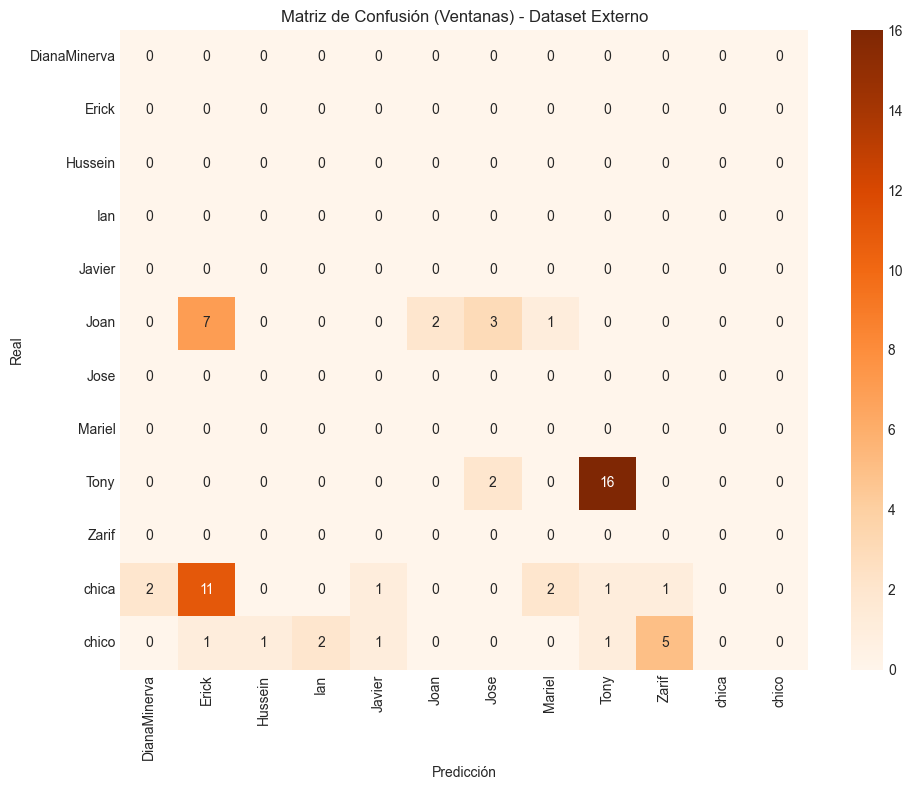

In [218]:
# Matriz de confusión por ventanas
all_labels_windows = sorted(set(y_ext_window_real_names.tolist() + y_ext_window_pred_names.tolist()))

cm_ext_win = confusion_matrix(y_ext_window_real_names, y_ext_window_pred_names, labels=all_labels_windows)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_ext_win,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=all_labels_windows,
    yticklabels=all_labels_windows,
)
plt.title("Matriz de Confusión (Ventanas) - Dataset Externo")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

### Discusión de Resultados

-  En primera instancia, y como se menciona anteriormente, al haber hecho el preprocesamiento de la forma en que se hizo, se quitan 2 videos de la clase Javier. Esto se hizo después de haber hecho un entrenamiento inicial y haber observado que cuando a los videos no se les recortó el final (los fallos en la coordenada z), se tenía un rendimiento pobre en todas las clases (menor a 0.3 de accuracy). Después de hacer el recorte adaptativo, se observó una mejora considerable en el rendimiento del modelo, pero se perdieron esos 2 videos pues las ventanas no cumplían con el número de frames requerido (de igual forma, se probó con ventanas de menos frames para tratar de incluir esos videos, pero el rendimiento de los modelos seguía siendo pobre). 

- Por lo anterior, también hay clases que tuvieron más ventanas de tiempo que otras, lo que influyó en el rendimiento del modelo. Hay con clases con suficientes muestras (en el entrenamiento), mientras que otras resultaron con muy pocas muestras, lo que dificultó el aprendizaje del modelo. Esto se puede observar en las matrices de confusión a nivel ventana del conjunto de entrenamiento, donde la clase 'Tony' tiene un rendimiento mucho mejor que la clase 'Joan', pues se contaba con más ventanas de tiempo para la clase 'Tony' que para la clase 'Joan' (42 vs 16). Si bien es cierto que hubiese sido preferible no eliminar tantos datos, después de haber probado con diferentes formas de preprocesamiento y aumentado de datos (rellenado de datos con interpolación), entrenado los modelos y evaluado su rendimiento, se decidió que esta era la mejor forma de preprocesar los datos para obtener un rendimiento aceptable, aunque se perdieran algunos videos.

- A sugerencia del profesor, se decidió reportar las métricas y matrices de confusión a nivel ventana y a nivel video. Esto para reflejar de mejor manera el rendimiento del modelo, pues a nivel ventana se tiene un rendimiento algo más reducido, mientras que a nivel video se tiene un rendimiento mucho mejor. Esto se debe a que aunque el modelo no clasifique correctamente todas las ventanas de un video, sí puede clasificar correctamente la mayoría de ellas, lo que permite asignar la etiqueta correcta al video.

- Respecto de los resultados de la validación externa, se observa que el modelo logra clasificar correctamente los videos de la clase 'Tony', mientras que de la clase 'Joan' solo logra clasificar uno. Esto es compatible con lo mencionado respecto del procesamiento realizado. Para mí, esto refleja la importancia de tener suficentes datos, pues de haber tenido más videos para la clase 'Joan', el modelo podría haber aprendido mejor las características de dicha clase, lo que podría haber mejorado el rendimiento del modelo en la validación externa.